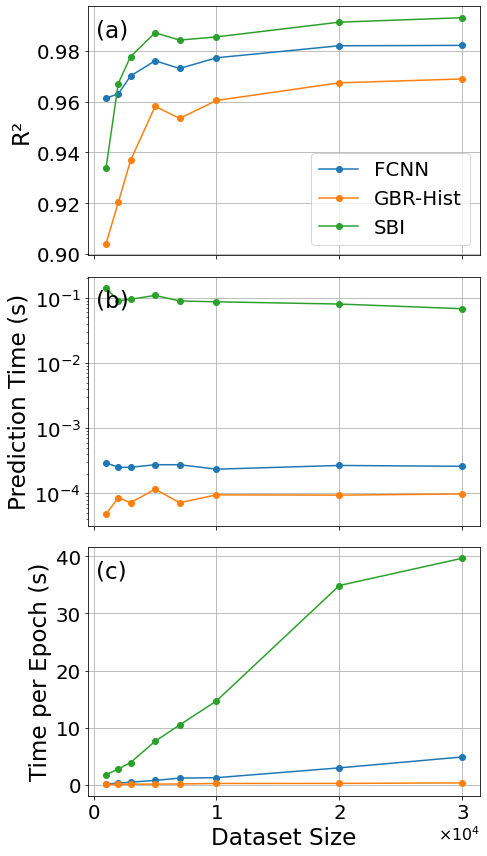

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Formatter for scientific notation on x-axis
sci_formatter = ScalarFormatter(useMathText=True)
sci_formatter.set_powerlimits((0, 0))  # force scientific notation

# ==========================
# Adjustable font sizes
# ==========================
scale = 1.1
label_fontsize = 21 * scale
title_fontsize = 24 * scale
legend_fontsize = 18 * scale
tick_fontsize = 18 * scale
annot_fontsize = 21 * scale

import numpy as np

# Data for the three models (FCNN, GBR-Hist, SBI)
dataset_sizes = [1000, 2000, 3000, 5000, 7000, 10000, 20000, 30000]

# R² values from the screenshots
r2_fcnn = [0.9613840376, 0.9630673188, 0.9700734894, 0.9760706644, 0.9730436392, 0.9772488967, 0.9819787832, 0.9821266072]
r2_gbr = [0.9040335778, 0.9203316349, 0.9368599906, 0.9581431707, 0.9533941216, 0.9604630355, 0.9673858919, 0.9689277022]
r2_sbi = [0.9338277802, 0.9671271646, 0.9777328951, 0.9870929404, 0.9842066315, 0.9854649569, 0.9912549488, 0.9930119344]

# FCNN Data from image_4097b1.png
fcnn_epochs = np.array([134, 156, 87, 146, 121, 78, 266, 79])
fcnn_training_times = np.array([24.50354, 50.126764, 42.110297, 116.543064, 144.93408, 99.210185, 795.130692, 386.370691])
fcnn_time_per_epoch = np.array([0.1828622388, 0.3213254103, 0.4840264023, 0.7982401644, 1.197802314, 1.271925449, 2.989213128, 4.890768241])
prediction_time_fcnn = [0.000295, 0.000251, 0.000251, 0.000275, 0.000275, 0.000235, 0.000268, 0.00026]

# GBR-Hist Data from image_4097ea.png
gbr_epochs = np.array([212, 214, 215, 234, 233, 208, 256, 250])
gbr_training_times = np.array([17.303884, 24.1699, 28.236458, 35.630937, 39.934885, 53.977968, 69.739402, 89.20029])
gbr_time_per_epoch = np.array([0.08162209434, 0.1129434579, 0.1313323628, 0.1522689615, 0.1713943562, 0.2595094615, 0.2724195391, 0.35680116])
prediction_time_gbr = [0.000048, 0.000086, 0.000072, 0.000116, 0.000072, 0.000095, 0.000094, 0.000098]

# SBI Data from image_409793.png
sbi_epochs = np.array([108, 193, 136, 181, 153, 114, 141, 155])
sbi_training_times = np.array([194.78905, 537.734902, 533.536723, 1383.632814, 1605.76924, 1675.370003, 4917.427656, 6144.55615])
sbi_time_per_epoch = np.array([1.803602315, 2.786191202, 3.92306414, 7.644380188, 10.49522379, 14.6962281, 34.87537345, 39.64229774])
prediction_time_sbi = [0.140299, 0.089906, 0.09421, 0.107958, 0.088839, 0.086228, 0.07967, 0.067584]

# ==========================
# Combined subplot figure
# ==========================
fig, axes = plt.subplots(3, 1, figsize=(7, 12), sharex=True)

# (a) R²
axes[0].plot(dataset_sizes, r2_fcnn, marker='o', label="FCNN")
axes[0].plot(dataset_sizes, r2_gbr, marker='o', label="GBR-Hist")
axes[0].plot(dataset_sizes, r2_sbi, marker='o', label="SBI")
axes[0].set_ylabel("R²", fontsize=label_fontsize)
axes[0].tick_params(labelsize=tick_fontsize)
axes[0].grid(True)
axes[0].text(0.02, 0.95, "(a)", transform=axes[0].transAxes, fontsize=annot_fontsize, va='top', ha='left')
axes[0].legend(loc='lower right', fontsize=legend_fontsize,
               framealpha=0.8, facecolor='white')

# (b) Prediction Time
axes[1].plot(dataset_sizes, prediction_time_fcnn, marker='o', label="FCNN")
axes[1].plot(dataset_sizes, prediction_time_gbr, marker='o', label="gbr-Hist")
axes[1].plot(dataset_sizes, prediction_time_sbi, marker='o', label="SBI")
axes[1].set_ylabel("Prediction Time (s)", fontsize=label_fontsize)
axes[1].set_yscale('log')
axes[1].tick_params(labelsize=tick_fontsize)
axes[1].grid(True)
axes[1].text(0.02, 0.95, "(b)", transform=axes[1].transAxes, fontsize=annot_fontsize, va='top', ha='left')

# (c) Time per Epoch
axes[2].plot(dataset_sizes, fcnn_time_per_epoch, marker='o', label="FCNN")
axes[2].plot(dataset_sizes, gbr_time_per_epoch, marker='o', label="gbr-Hist")
axes[2].plot(dataset_sizes, sbi_time_per_epoch, marker='o', label="SBI")
axes[2].set_ylabel("Time per Epoch (s)", fontsize=label_fontsize)
axes[2].set_xlabel("Dataset Size", fontsize=label_fontsize)
axes[2].tick_params(labelsize=tick_fontsize)
axes[2].grid(True)
axes[2].text(0.02, 0.95, "(c)", transform=axes[2].transAxes, fontsize=annot_fontsize, va='top', ha='left')
axes[2].xaxis.get_offset_text().set_fontsize(tick_fontsize*0.8)
axes[2].yaxis.get_offset_text().set_fontsize(tick_fontsize*0.8)



# Apply sci-notation formatter to x-axis (all subplots share x)
for ax in axes:
    ax.xaxis.set_major_formatter(sci_formatter)

plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/dataset_size.pdf", dpi=300, facecolor='white')
plt.show()


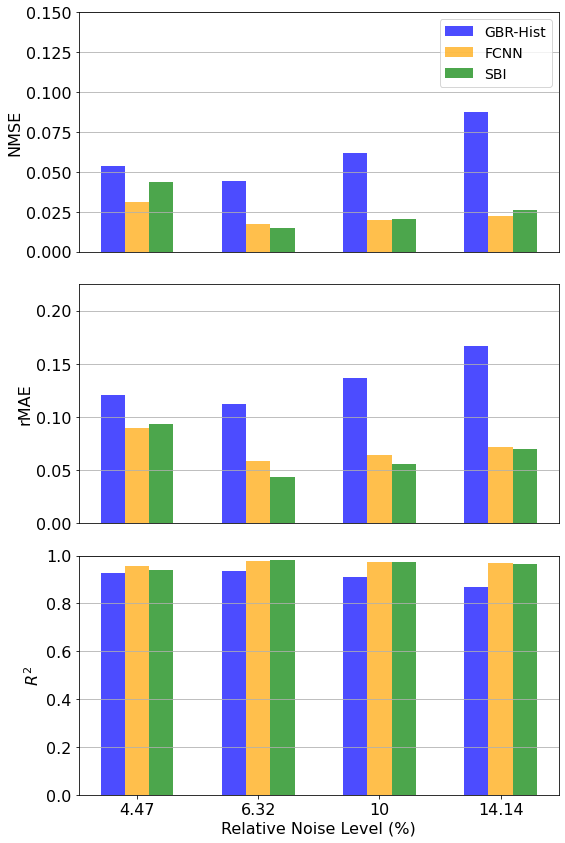

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==== Adjustable font size ====
base_fontsize = 16   # change this once to scale everything

# Data for FCNN, gbr-Hist, and SBI models
noise_levels = [4.47, 6.32, 10, 14.14]

# FCNN results
fcnn_mse = [0.031244166387682674, 0.017113730849660613, 0.01964889390945118, 0.022215993347311648]
fcnn_mae = [0.08988697324355015, 0.05897304421195917, 0.06456693967129817, 0.07175107038869485]
fcnn_r2   = [0.9562192802741052, 0.9768257625580401, 0.9733777331086237, 0.96983906145859]

# gbr-Hist results
gbr_mse = [0.05345368350898983, 0.04414786024568498, 0.06186121608331685, 0.08745308951840632]
gbr_mae = [0.12087397106634884, 0.11190682400291098, 0.13662210527647795, 0.16675653984408148]
gbr_r2   = [0.924995197258802, 0.9366272354683549, 0.9090768090043495, 0.8680559489418651]

# SBI results
sbi_mse = [0.043624384198197516, 0.015041731418487348, 0.020466176514585654, 0.025965803667753414]
sbi_mae = [0.09352532780845627, 0.04308684727825167, 0.05590203995463241, 0.06960905815805946]
sbi_r2   = [0.9382048759846137, 0.9800148508328324, 0.9726652438463887, 0.9648662575489075]

# Setting up the figure
plt.figure(figsize=(8, 12))
plt.rcParams.update({'font.size': base_fontsize})

bar_width = 0.2
x_indices = np.arange(len(noise_levels))

# === NMSE subplot ===
plt.subplot(3, 1, 1)
plt.bar(x_indices - bar_width, gbr_mse, bar_width, label='GBR-Hist', color='blue', alpha=0.7)   # left
plt.bar(x_indices, fcnn_mse, bar_width, label='FCNN', color='orange', alpha=0.7)                # middle
plt.bar(x_indices + bar_width, sbi_mse, bar_width, label='SBI', color='green', alpha=0.7)       # right
plt.ylabel('NMSE', fontsize=base_fontsize)
plt.legend(fontsize=base_fontsize-2)
plt.grid(True)
plt.xticks([])  # hide xticks
plt.ylim(0, 0.15)

# === rMAE subplot ===
plt.subplot(3, 1, 2)
plt.bar(x_indices - bar_width, gbr_mae, bar_width, label='GBR-Hist', color='blue', alpha=0.7)
plt.bar(x_indices, fcnn_mae, bar_width, label='FCNN', color='orange', alpha=0.7)
plt.bar(x_indices + bar_width, sbi_mae, bar_width, label='SBI', color='green', alpha=0.7)
plt.ylabel('rMAE', fontsize=base_fontsize)
plt.grid(True)
plt.xticks([])
plt.ylim(0, 0.225)

# === R² subplot ===
plt.subplot(3, 1, 3)
plt.bar(x_indices - bar_width, gbr_r2, bar_width, label='GBR-Hist', color='blue', alpha=0.7)
plt.bar(x_indices, fcnn_r2, bar_width, label='FCNN', color='orange', alpha=0.7)
plt.bar(x_indices + bar_width, sbi_r2, bar_width, label='SBI', color='green', alpha=0.7)
plt.xlabel('Relative Noise Level (%)', fontsize=base_fontsize)
plt.ylabel(r'$R^2$', fontsize=base_fontsize)
plt.xticks(x_indices, noise_levels, fontsize=base_fontsize)
plt.ylim(0, 1)
plt.grid(axis='y')

# Adjust layout
plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/noise_comparison.pdf", dpi=300, facecolor='white')
plt.show()


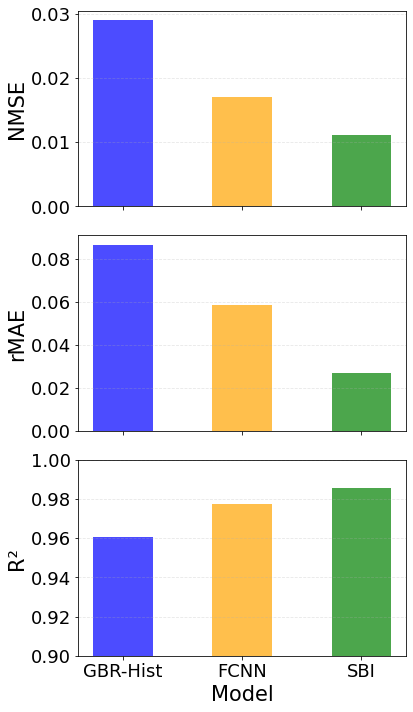

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Adjustable font sizes
# --------------------------
BASE_LABEL = 14
BASE_TICK  = 12
SCALE = 1.5   # adjust this multiplier as needed

label_fs = int(BASE_LABEL * SCALE)
tick_fs  = int(BASE_TICK  * SCALE)

# Data
models = ['GBR-Hist', 'FCNN', 'SBI']
colors = ['blue', 'orange', 'green']   # consistent color mapping


nmse = [
    0.029079160032190885,  # GBR-Hist
    0.01707678923331455,   # FCNN
    0.01120965594918381    # SBI
]

rmae = [
    0.08651701482217763,   # GBR-Hist
    0.05863251113150782,   # FCNN
    0.027101349199376065   # SBI
]

r2 = [
    0.9604630355072175,    # GBR-Hist
    0.9772488967193496,    # FCNN
    0.9854649569357746     # SBI
]

# --------------------------
# Plot: 3 rows, shared x-axis
# --------------------------
fig, axes = plt.subplots(3, 1, figsize=(6, 10), sharex=True)

# (1) NMSE
axes[0].bar(models, nmse, color=colors, width=0.5, alpha=0.7)
axes[0].set_ylabel('NMSE', fontsize=label_fs)
axes[0].tick_params(axis='both', labelsize=tick_fs)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# (2) rMAE
axes[1].bar(models, rmae, color=colors, width=0.5, alpha=0.7)
axes[1].set_ylabel('rMAE', fontsize=label_fs)
axes[1].tick_params(axis='both', labelsize=tick_fs)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

# (3) R²
axes[2].bar(models, r2, color=colors, width=0.5, alpha=0.7)
axes[2].set_ylabel('R²', fontsize=label_fs)
axes[2].set_xlabel('Model', fontsize=label_fs)
axes[2].set_ylim(0.9, 1.0)
axes[2].tick_params(axis='both', labelsize=tick_fs)
axes[2].grid(axis='y', linestyle='--', alpha=0.3)

# Hide repeated x labels on upper subplots
for ax in axes[:-1]:
    ax.label_outer()

plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/whole_model.pdf", dpi=300, facecolor='white')
plt.show()


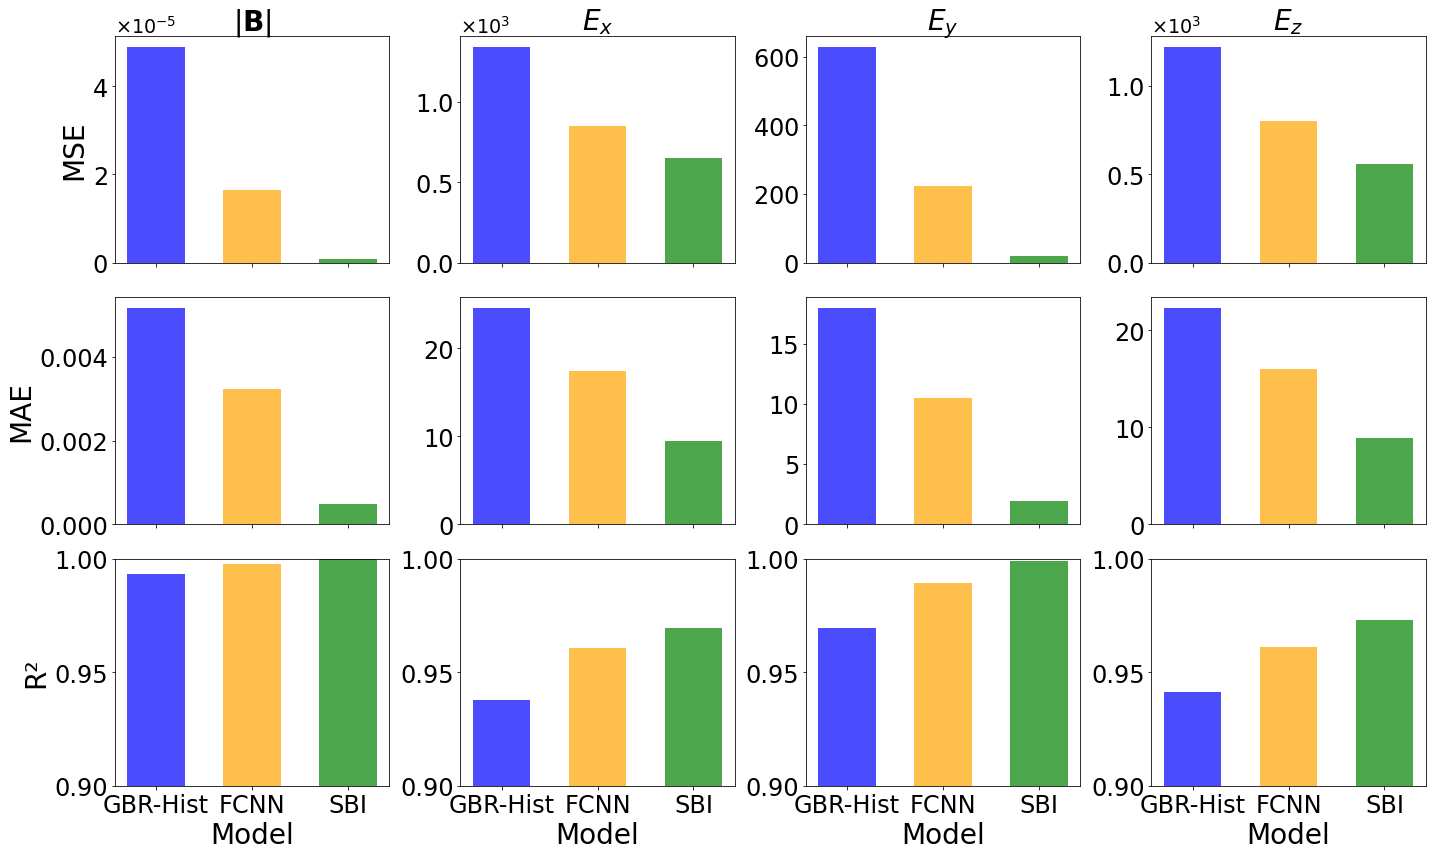

In [4]:
# Component-wise metrics
component_mse = [
    [4.898778351136203e-05, 1342.0474897109987, 628.951882432145, 1222.1178831687923],   # GBR-Hist
    [1.6505325484246186e-05, 849.9569934941782, 222.10545143805854, 803.1014409039304],  # FCNN
    [8.912445354059157e-07, 653.2097698214036, 18.283991254228432, 559.4134013404923]    # SBI
]

component_mae = [
    [0.00517109074940186, 24.567922517664435, 17.960644225167677, 22.271675453344354],    # GBR-Hist
    [0.0032316386595883876, 17.40018429735886, 10.47035925079184, 16.044801104077102],    # FCNN
    [0.0004917794519134134, 9.411840385723266, 1.9668325235611064, 8.921051853740327]     # SBI
]

component_r2 = [
    [0.9932707895685347, 0.9378496156403794, 0.9694538771067602, 0.9412778597131952],    # GBR-Hist
    [0.9977327447689573, 0.960638387061708, 0.9892130692277284, 0.9614113858190043],     # FCNN
    [0.9998775741298185, 0.9697497751956587, 0.9991120067219278, 0.9731204716956933]     # SBI
]

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Make formatter for scientific notation
sci_formatter = ScalarFormatter(useMathText=True)
sci_formatter.set_scientific(True)
sci_formatter.set_powerlimits((-3, 3))
sci_formatter.set_useOffset(False)



# ---------------------------
# Adjustable font sizes
# ---------------------------
BASE_LABEL = 14
BASE_TICK  = 12
BASE_TITLE = 14
SCALE = 2   # <- bump this (e.g., 1.3) to scale all fonts

label_fs = int(BASE_LABEL * SCALE)
tick_fs  = int(BASE_TICK  * SCALE)
title_fs = int(BASE_TITLE * SCALE)

# Models & consistent colors
models = ['GBR-Hist', 'FCNN', 'SBI']
model_colors = ['blue', 'orange', 'green']  # same mapping across all plots

components = ['$|\mathbf{B}|$', '$E_x$', '$E_y$', '$E_z$']
metrics = ['MSE', 'MAE', 'R²']

# --- your data objects must already exist:
# component_mse, component_mae, component_r2  (shape: 3 models × 4 components)

# 3 rows (MSE/MAE/R²) × 4 columns (B3/E1/E2/E3)
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex='col', sharey=False)
for axrow in axes:
    for ax in axrow:
        ax.tick_params(labelleft=True)  # force show y labels


# Apply to first row only
for ax in axes[0, :]:   # row 0, all 4 columns
    ax.yaxis.set_major_formatter(sci_formatter)

for i, metric in enumerate([component_mse, component_mae, component_r2]):
    for j, comp in enumerate(components):
        ax = axes[i, j]
        # heights for GBR-Hist, FCNN, SBI for this component
        vals = [metric[k][j] for k in range(len(models))]
        ax.bar(models, vals, color=model_colors, width=0.6, alpha=0.7)

        # Y label only on the leftmost column
        if j == 0:
            ax.set_ylabel(metrics[i], fontsize=label_fs)

        # Column titles only on the top row
        if i == 0:
            ax.set_title(comp, fontsize=title_fs)

        # R² range
        if metrics[i] == 'R²':
            ax.set_ylim(0.9, 1.0)
            ax.set_yticks([0.90, 0.95, 1.00])   # <- force exact ticks


        # ticks
        ax.tick_params(axis='both', labelsize=tick_fs)
        ax.xaxis.get_offset_text().set_fontsize(tick_fs*0.8)
        ax.yaxis.get_offset_text().set_fontsize(tick_fs*0.8)

# Only bottom row shows x labels (shared within each column)
for ax in axes[0, :]:
    ax.label_outer()  # hide x tick labels on top row
for ax in axes[1, :]:
    ax.label_outer()  # hide x tick labels on middle row
for ax in axes[2, :]:
    ax.set_xlabel('Model', fontsize=label_fs)

plt.tight_layout()
# Force y-ticks and labels visible on every subplot
for axrow in axes:
    for ax in axrow:
        ax.tick_params(labelleft=True)   # turn on tick labels
        for label in ax.get_yticklabels():
            label.set_visible(True)      # ensure visibility

plt.savefig("/home/botingl/machine learning copy/Plots/component_wise.pdf", dpi=300, facecolor='white')
plt.show()

